# Force Field Reparametrization - Veloxchem 

I frist ran a geometry optimization using Gaussian on the wb97xd/def2svp level of theory. Let's extract the final optimized geometry as a .xyz file.

In [4]:
import cclib

elements = [
    None, "H", "He",
    "Li", "Be", "B", "C", "N", "O", "F", "Ne",
    "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar",
    # etc.
]

data = cclib.io.ccread("geometry optimization/again/Py_Et_Py.log")

coords = data.atomcoords[-1]

with open("optimized.xyz", "w") as f:
    f.write(f"{data.natom}\n")
    f.write("Optimized geometry\n")

    for atomic_number, (x, y, z) in zip(data.atomnos, coords):
        element = elements[atomic_number]
        f.write(f"{element} {x:.8f} {y:.8f} {z:.8f}\n")

Now let's visulaize the optimized structure with VeloxChem. 

In [5]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_file('optimized.xyz')
molecule.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Next, we need to run a relaxed scan of our torsional coorindate for which we would like to parametrize the force field later on. For us we would like to scan `D 1 2 3 4 S 20 18.0` I did this again in Gaussian from 0° to 360° in steps of 20°. Veloxchem later on needs the optimized scan geometries and files as a .xyz trajectory. For this I am using the `gaussian2xyz.py` script. To extact the geometries we can run `python gaussian2xyz.py scanfile.log scan > scan.xyz`. Afterwards we need to convert the `scan.xyz` into the proper format for veloxchem whose file name should be `i-j-k-l.xzy` with `i, j, k, l` being the atom indices of the dihedral. For this you can use the python script `get_scan.py`.

A useful tool, to visulize the trajectory: https://www.prs.wiki/utilities/xyz-trajectory

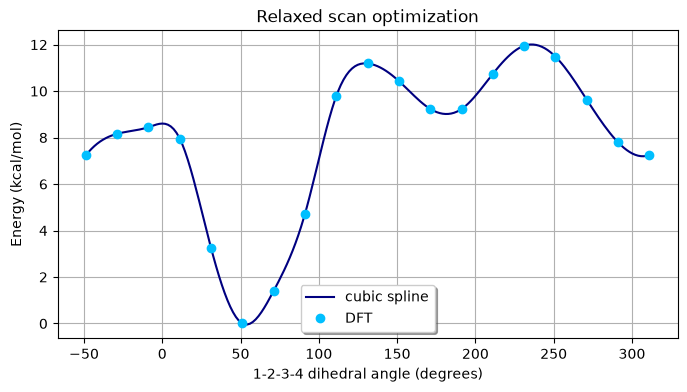

In [22]:
import numpy as np
import scipy
from matplotlib import pyplot as plt

data = np.loadtxt('torsional scan/scan_energy.dat', skiprows=2, usecols=[0, -1])
occc = data[:,0]
energy_scan = data[:,1]

spline_func = scipy.interpolate.interp1d(occc, energy_scan, kind="cubic")

x_spline = np.linspace(occc[0], occc[-1], 200)
y_spline = spline_func(x_spline)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x_spline, y_spline, "-", color="navy", label="cubic spline")
ax.plot(occc, energy_scan, "o", color="deepskyblue", label="DFT")

ax.legend(frameon=True, shadow=True, loc="lower center")

ax.grid(True)

ax.set_title("Relaxed scan optimization")
ax.set_xlabel("1-2-3-4 dihedral angle (degrees)")
ax.set_ylabel("Energy (kcal/mol)")

plt.show()

We also need to calculate RESP charges for the force field. For this we will use veloxchem directly. 

In [2]:
basis = vlx.MolecularBasis.read(molecule, "6-31G*", ostream=None)
scf_drv = vlx.ScfRestrictedDriver()
scf_results = scf_drv.compute(molecule, basis)
resp_drv = vlx.RespChargesDriver()
resp_charges = resp_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [5]:
import numpy as np
print(resp_charges)
np.savetxt('RESP_charges.txt', resp_charges)
print("Atom     RESP charge")
print(20 * "-")

for label, resp_charge in zip(molecule.get_labels(), resp_charges):
    print(f"{label :s} {resp_charge : 18.6f}")

print(20 * "-")

print(f"Total: {resp_charges.sum() : 13.6f}")

[-0.0199701  -0.00903079 -0.01548516 -0.01773976  0.00849581  0.0409278
  0.08929666  0.06196782 -0.22661871 -0.1596677  -0.17159085 -0.20733944
 -0.14416287  0.04156053 -0.21007745 -0.18631447  0.05810663 -0.15815293
 -0.22165674  0.01586375  0.04964425  0.07514482 -0.16298361 -0.22978926
  0.06284698 -0.15515464 -0.22569672 -0.13992163  0.04245093 -0.20577844
 -0.18888284  0.06215106 -0.1764725  -0.2042622   0.02631742  0.02631742
  0.03116755  0.03116755  0.14812458  0.15346556  0.14686158  0.15792745
  0.13751843  0.15003634  0.14607174  0.1449611   0.16938196  0.15309509
  0.14876579  0.14329609  0.163879    0.1379681   0.14877901  0.14697818
  0.14818034  0.16803148]
Atom     RESP charge
--------------------
C          -0.019970
C          -0.009031
C          -0.015485
C          -0.017740
C           0.008496
C           0.040928
C           0.089297
C           0.061968
C          -0.226619
C          -0.159668
C          -0.171591
C          -0.207339
C          -0.144163
C  

Now we can finally parametrize the force field. 

In [59]:
import numpy as np 

ff_gen = vlx.MMForceFieldGenerator()
ff_gen.partial_charges = np.loadtxt('RESP_charges.txt')
ff_gen.create_topology(molecule)
print(ff_gen.rotatable_bonds)

* Info * Using GAFF (v2.11) parameters.                                                                                   
         Reference: J. Wang, R. M. Wolf, J. W. Caldwell, P. A. Kollman, D. A. Case, J. Comput. Chem. 2004,
         25, 1157-1174.
                                                                                                                          
[[2, 3], [3, 4], [1, 2]]


                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 2-3                                                                                     
* Info * Dihedrals involved:[[1, 2, 3, 4], [1, 2, 3, 37], [1, 2, 3, 38], [4, 3, 2, 35], [4, 3, 2, 36], [35, 2, 3, 37], [35, 2, 3, 38], [36, 2, 3, 37], [36, 2, 3, 38]]
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   torsional scan/1-2-3-4.xyz                                                                                     
                                                                                               

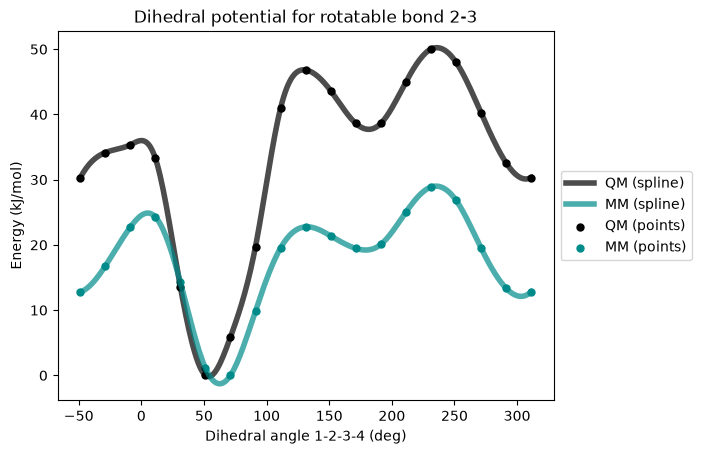

* Info * Fitting the dihedral parameters...                                                                               
* Info * Optimizing dihedral via least squares fitting...                                                                 
* Info * New fitted barriers: [2.44866785 2.44866785 2.44866785 2.44866785 2.44866785 1.25815683
 1.25815683 1.25815683 1.25815683]
                                                                                                                          
* Info * Validating the fitted force field...                                                                             
                                                                                                                          
* Info * Summary of validation                                                                                            
* Info * ---------------------                                                                                            
* Info 

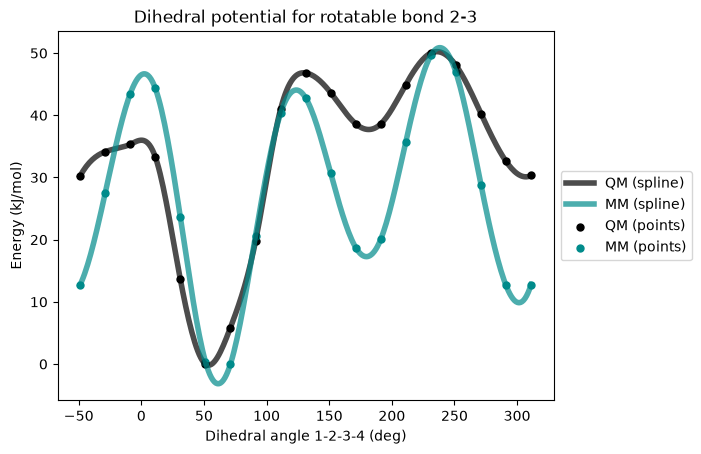

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


In [60]:
reparam_summary = ff_gen.reparameterize_dihedrals(rotatable_bond=(2,3),
                                                  scan_file="torsional scan/1-2-3-4.xyz",
                                                  visualize=True,
                                                  verbose=False)

As you can see, it is not uncommon that the existing dihedral terms in the force field are not sufficient to reproduce the QM potential. Here we can try adding more dihedral terms to the force field, and then redo the fitting. 

In this particular case we would like to lower the MM energy at 0° so that it matches the QM energy better. This corresponds to adding a dihedral term with periodicity 1 and phase 180°. The barrier can be set to 0 since it will be fitted.

In [87]:
ff_gen.add_dihedral((1, 2, 3, 4), barrier=0.0, phase=0.0, periodicity=1)

* Info * Added dihedral 1-2-3-4                                                                                           


After this we can refit again using the same command as before (now I am also plotting the difference). 

                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 2-3                                                                                     
* Info * Dihedrals involved:[[1, 2, 3, 4], [1, 2, 3, 37], [1, 2, 3, 38], [4, 3, 2, 35], [4, 3, 2, 36], [35, 2, 3, 37], [35, 2, 3, 38], [36, 2, 3, 37], [36, 2, 3, 38]]
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   torsional scan/1-2-3-4.xyz                                                                                     
                                                                                               

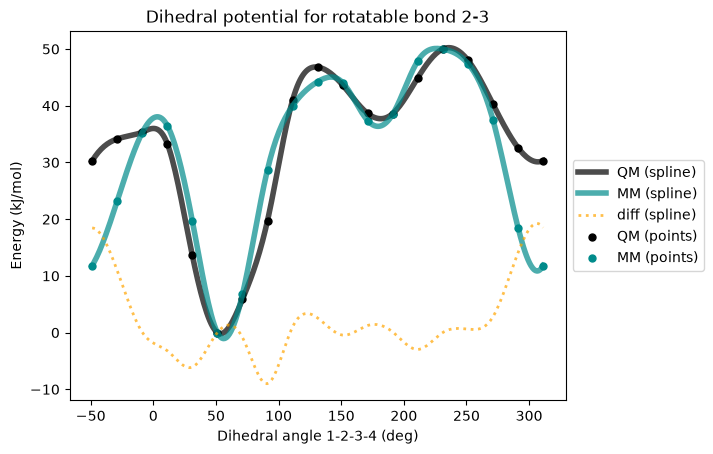

* Info * Fitting the dihedral parameters...                                                                               
* Info * Optimizing dihedral via least squares fitting...                                                                 
* Info * New fitted barriers: [5.98459007e+00 8.81222411e+00 6.23881796e-03 4.49724018e+01
 3.36030563e+00 3.46728548e+00 2.03401584e+00 1.29209462e-01
 4.40210833e+00 6.25878726e+00 1.46446027e+01 2.07255097e-01
 7.29168845e-08 5.98459007e+00 5.98459007e+00 5.98459007e+00
 5.98459007e+00 2.91498989e+00 2.91498989e+00 2.91498989e+00
 2.91498989e+00]
                                                                                                                          
* Info * Validating the fitted force field...                                                                             
                                                                                                                          
* Info * Summary of validation   

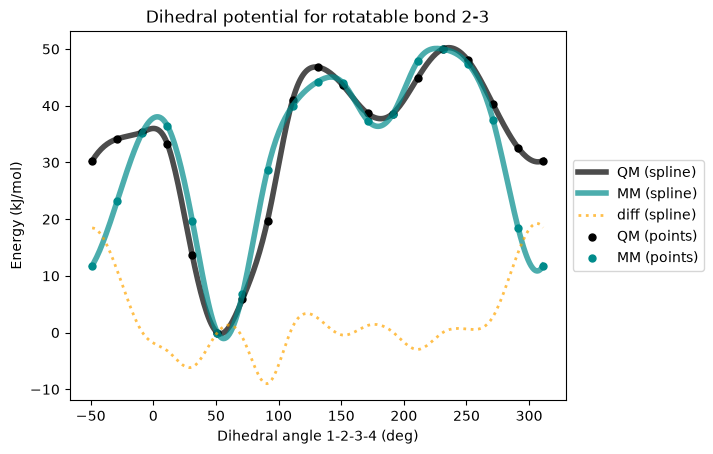

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


In [88]:
reparam_summary = ff_gen.reparameterize_dihedrals(rotatable_bond=(2,3),
                                                  scan_file="torsional scan/1-2-3-4.xyz",
                                                  visualize=True,
                                                  show_diff=True,
                                                  verbose=False)

Okay let's not do this randomly, let's plot the results and check which dihedral with what phase and peridocity would fit best. The dihedral potential that is used has the form: 

$$ V = V_0 (1 + \cos (n \theta - \gamma))$$

where $V_0$ is the barrier height, $\theta$ the dihedral angle, $n$ the periodicity and $\gamma$ the phase shift. Note that you can only integer values are allowed for $n$ and the phase can either be 0° or 180°. In essence, we just add more and more dihedrals with higher periodicity until the MM energies closely match the QM ones. Just re-run the above two cells until you get a satisfactory result. You can check with the code below what adding a certain dihedral looks like without fitting. 

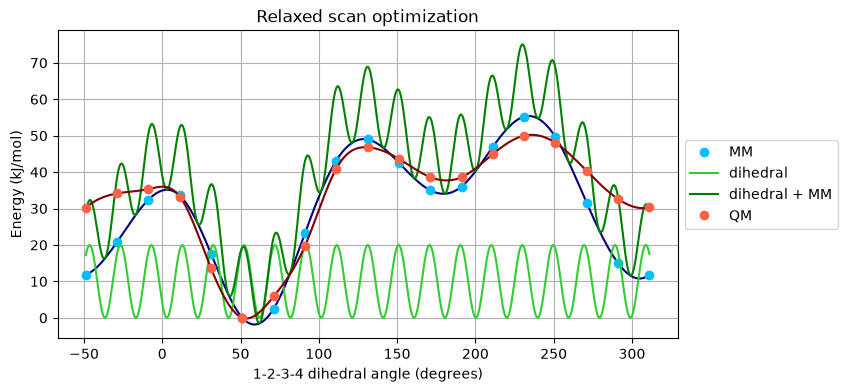

In [66]:
angles = reparam_summary['dihedral_angles']
mm = reparam_summary['mm_scan_kJpermol']
qm = reparam_summary['qm_scan_kJpermol'] 

# dihedral parameters
# only integer parameters allowed
n = 2
# only 0° or 180° allowed
phase = 180
barrier = +10

# make figure
fig, ax = plt.subplots(figsize=(8, 4))

# plot MM
spline_func = scipy.interpolate.interp1d(angles, mm, kind="cubic")
x_spline = np.linspace(angles[0], angles[-1], 500)
y_spline = spline_func(x_spline)
ax.plot(x_spline, y_spline, "-", color="navy")
ax.plot(angles, mm, "o", color="deepskyblue", label="MM")

# plot dihedral
Vd = barrier*(1 + np.cos(n*x_spline/(2*np.pi) - phase))
ax.plot(x_spline, Vd, "-", color="limegreen", label='dihedral')

# plot dihedral + barrier 
ax.plot(x_spline, Vd+y_spline, "-", color="g", label='dihedral + MM')

# plot QM
spline_func = scipy.interpolate.interp1d(angles, qm, kind="cubic")
x_spline = np.linspace(angles[0], angles[-1], 500)
y_spline = spline_func(x_spline)
ax.plot(x_spline, y_spline, "-", color="maroon")
ax.plot(angles, qm, "o", color="tomato", label="QM")

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True)
ax.set_title("Relaxed scan optimization")
ax.set_xlabel("1-2-3-4 dihedral angle (degrees)")
ax.set_ylabel("Energy (kJ/mol)")

plt.show()

Finially, we can generate the topology files needed for GROMAS using:

In [89]:
ff_gen.write_gromacs_files("Py_Et_Py", "PYR")
